# Phase 3 — model training, comparison, and visualization

This reconstructed, executable notebook is the retained Phase 3 analysis code. It reads the frozen Phase 2 workbook, trains the supervised spatial-ranking model, fits independent D1-only unsupervised regimes, compares both outputs, and writes a retained result workbook and Matplotlib PNG figures. The supervised Primary score remains the only numerical ranking.

Run with Python 3.12+ and `pandas`, `numpy`, and `openpyxl`. The notebook deliberately uses NumPy implementations of ridge logistic regression, PCA, K-means, and silhouette diagnostics, so it does not require scikit-learn.

In [1]:
from pathlib import Path
from hashlib import sha256
from html import escape
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

def find_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'outputs' / 'Data center' / 'TN').exists():
            return candidate
    raise FileNotFoundError('Run from this project or a child directory.')

ROOT = find_root()
_support = ROOT / 'outputs' / 'Data center' / 'TN' / 'model' / 'notebook_support'
import sys
sys.path.insert(0, str(_support)) if str(_support) not in sys.path else None
from tn_common import apply_plot_theme, finish_figure, sigmoid, weighted_auc
from phase3_data import empirical_percentile, log_standardize, make_training_table
PHASE2 = ROOT / 'outputs/Data center/TN/model/phase 2/dataset/phase2_model_dataset.xlsx'
RESULTS = ROOT / 'outputs/Data center/TN/model/phase 3/results'
FIGURES = RESULTS / 'figures'
RESULTS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
PHASE2_SHA256 = sha256(PHASE2.read_bytes()).hexdigest()
assert PHASE2_SHA256 == '112d6db67d7f4f9e74fa8edde3406937e1f8eb7145e9bc04a64e7030cf1d3e03'
print(f'Frozen Phase 2 hash verified: {PHASE2_SHA256}')

Frozen Phase 2 hash verified: 112d6db67d7f4f9e74fa8edde3406937e1f8eb7145e9bc04a64e7030cf1d3e03


In [2]:
# Frozen inputs and permitted predictors
sites = pd.read_excel(PHASE2, sheet_name='Presence_Sites')
domain = pd.read_excel(PHASE2, sheet_name='Domain_Cells')
background = pd.read_excel(PHASE2, sheet_name='Background_Samples')
contract = pd.read_excel(PHASE2, sheet_name='Phase3_Training_Contract')

D1 = domain.loc[domain['d1_feasible'].eq(True)].copy().reset_index(drop=True)
assert len(D1) == 4391 and D1['cell_id'].is_unique
SUPERVISED_FEATURES = [
    'dist_major_road_km',
    'dist_transmission_any_km',
    'dist_surface_water_flowline_km',
]
UNSUPERVISED_FEATURES = contract.loc[contract['field_class'].eq('numeric predictor proxy'), 'field'].tolist()
assert len(UNSUPERVISED_FEATURES) == 21
assert set(SUPERVISED_FEATURES).issubset(UNSUPERVISED_FEATURES)
assert D1[UNSUPERVISED_FEATURES].notna().all().all()
print({'D1_cells': len(D1), 'presence_rows': len(sites), 'background_rows': len(background), 'unsupervised_features': len(UNSUPERVISED_FEATURES)})

{'D1_cells': 4391, 'presence_rows': 74, 'background_rows': 41400, 'unsupervised_features': 21}


In [3]:
# Reusable numerical routines. Labels, IDs, coordinates, strata, and fold groups never enter X.
def fit_ridge_logistic(x, y, sample_weight, penalty=1.0, max_iter=100, tol=1e-8):
    x = np.column_stack([np.ones(len(x)), x])
    beta = np.zeros(x.shape[1])
    ridge = np.r_[0.0, np.repeat(penalty, x.shape[1] - 1)]
    for _ in range(max_iter):
        p = sigmoid(x @ beta)
        w = np.maximum(sample_weight * p * (1 - p), 1e-10)
        grad = x.T @ (sample_weight * (y - p)) - ridge * beta
        hessian = (x.T * w) @ x + np.diag(ridge)
        step = np.linalg.solve(hessian + np.eye(len(beta)) * 1e-10, grad)
        beta_next = beta + step
        if np.max(np.abs(step)) < tol:
            return beta_next
        beta = beta_next
    raise RuntimeError('Logistic model did not converge.')

empirical_score = lambda values: np.asarray(empirical_percentile(values))
training_table = lambda scenario, draw: make_training_table(sites, D1, background, scenario, draw, SUPERVISED_FEATURES)


In [4]:
# Spatial model comparison: scenario × draw × held-out grand region.
spatial_runs = []
for scenario in ('primary', 'weighted', 'strict'):
    for draw in range(1, 21):
        table = training_table(scenario, draw)
        for held_out in ('west', 'middle', 'east'):
            train = table.loc[table['grand_region'] != held_out]
            test = table.loc[table['grand_region'] == held_out]
            x_train, x_test, _, _ = log_standardize(train, test, SUPERVISED_FEATURES)
            beta = fit_ridge_logistic(x_train, train['label'].to_numpy(), train['sample_weight'].to_numpy())
            test_score = np.column_stack([np.ones(len(x_test)), x_test]) @ beta
            spatial_runs.append({
                'scenario': scenario, 'draw': draw, 'held_out_region': held_out,
                'n_train': len(train), 'n_test': len(test),
                'held_out_weighted_auc': weighted_auc(test['label'], test_score, test['sample_weight']),
                **{f'coefficient_{name}': value for name, value in zip(SUPERVISED_FEATURES, beta[1:])},
            })
spatial_runs = pd.DataFrame(spatial_runs)
validation_summary = spatial_runs.groupby(['scenario', 'held_out_region'], as_index=False).agg(
    median_auc=('held_out_weighted_auc', 'median'), p05_auc=('held_out_weighted_auc', lambda x: x.quantile(.05)),
    model_runs=('draw', 'size')
)
assert (validation_summary['model_runs'] == 20).all()
display(validation_summary.round(4))

,scenario,held_out_region,median_auc,p05_auc,model_runs
0,primary,east,0.8793,0.8578,20
1,primary,middle,0.8417,0.8355,20
2,primary,west,0.7243,0.7088,20
3,strict,east,0.8623,0.8456,20
4,strict,middle,0.8564,0.8520,20
5,strict,west,0.7574,0.7438,20
6,weighted,east,0.8614,0.8446,20
7,weighted,middle,0.8578,0.8522,20
8,weighted,west,0.7567,0.7438,20


In [5]:
# Full D1 Primary ranking. Each draw is fitted on all Primary rows and its registered 10:1 background draw.
all_logits, full_runs = [], []
for draw in range(1, 21):
    table = training_table('primary', draw)
    x_train, x_d1, mean_x, scale_x = log_standardize(table, D1, SUPERVISED_FEATURES)
    beta = fit_ridge_logistic(x_train, table['label'].to_numpy(), table['sample_weight'].to_numpy())
    all_logits.append(np.column_stack([np.ones(len(x_d1)), x_d1]) @ beta)
    full_runs.append({'scenario': 'primary', 'draw': draw, 'intercept': beta[0], **dict(zip(SUPERVISED_FEATURES, beta[1:]))})
logits = np.vstack(all_logits)
predictions = D1[['cell_id', 'centroid_lat', 'centroid_lon', 'grand_region']].copy()
predictions['primary_median_logit'] = np.median(logits, axis=0)
predictions['primary_empirical_score'] = empirical_score(predictions['primary_median_logit'])
draw_scores = np.vstack([empirical_score(row) for row in logits])
predictions['primary_draw_rank_p05'] = np.quantile(draw_scores, .05, axis=0)
predictions['primary_draw_rank_p50'] = np.quantile(draw_scores, .50, axis=0)
predictions['primary_draw_rank_p95'] = np.quantile(draw_scores, .95, axis=0)
predictions['primary_draw_rank_iqr'] = np.quantile(draw_scores, .75, axis=0) - np.quantile(draw_scores, .25, axis=0)
predictions['primary_band'] = pd.cut(predictions['primary_empirical_score'], [-np.inf, 50, 75, 90, np.inf], labels=['lower_empirical_affinity', 'watchlist', 'priority_2', 'priority_1'], right=False)
assert predictions['primary_empirical_score'].between(0, 100).all()
display(predictions['primary_band'].value_counts(dropna=False))

primary_band
lower_empirical_affinity    2195
watchlist                   1098
priority_2                   658
priority_1                   440
Name: count, dtype: int64

In [6]:
# D1-only unsupervised model: log1p, robust scaling, PCA, deterministic K-means, and sampled silhouette.
def robust_scale(frame, features):
    x = np.log1p(frame[features].to_numpy(float))
    med = np.median(x, axis=0)
    iqr = np.quantile(x, .75, axis=0) - np.quantile(x, .25, axis=0)
    fallback = x.std(axis=0, ddof=0)
    scale = np.where(iqr > 0, iqr, np.where(fallback > 0, fallback, 1.0))
    return (x - med) / scale, med, scale

def kmeans(x, k, seed=4701, starts=12, iterations=200):
    rng = np.random.default_rng(seed)
    best = None
    for _ in range(starts):
        centers = x[rng.choice(len(x), size=k, replace=False)].copy()
        for __ in range(iterations):
            dist2 = ((x[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
            labels = dist2.argmin(axis=1)
            next_centers = np.vstack([x[labels == j].mean(axis=0) if (labels == j).any() else centers[j] for j in range(k)])
            if np.allclose(next_centers, centers):
                break
            centers = next_centers
        inertia = ((x - centers[labels]) ** 2).sum()
        if best is None or inertia < best[0]:
            best = inertia, labels, centers
    return best

def sampled_silhouette(x, labels, sample_n=800, seed=4701):
    rng = np.random.default_rng(seed)
    take = rng.choice(len(x), min(sample_n, len(x)), replace=False)
    z, g = x[take], labels[take]
    distances = np.sqrt(((z[:, None, :] - z[None, :, :]) ** 2).sum(axis=2))
    values = []
    for i, label in enumerate(g):
        own = g == label
        a = distances[i, own].sum() / max(own.sum() - 1, 1)
        b = min(distances[i, g == other].mean() for other in np.unique(g) if other != label)
        values.append((b - a) / max(a, b, 1e-12))
    return float(np.mean(values))

z, _, _ = robust_scale(D1, UNSUPERVISED_FEATURES)
u, singular, vt = np.linalg.svd(z, full_matrices=False)
variance = singular ** 2 / (len(z) - 1)
explained = variance / variance.sum()
n_pc = max(2, int(np.searchsorted(np.cumsum(explained), .80) + 1))
pc = z @ vt[:n_pc].T
diagnostics, fits = [], {}
for k in range(2, 9):
    inertia, labels, centers = kmeans(pc, k)
    diagnostics.append({'k': k, 'sampled_silhouette': sampled_silhouette(pc, labels), 'inertia': inertia, 'minimum_regime_size': int(pd.Series(labels).value_counts().min())})
    fits[k] = (labels, centers)
cluster_diagnostics = pd.DataFrame(diagnostics)
selected_k = int(cluster_diagnostics.sort_values(['sampled_silhouette', 'minimum_regime_size'], ascending=[False, False]).iloc[0]['k'])
labels, centers = fits[selected_k]
regimes = D1[['cell_id']].copy()
regimes['regime_id'] = pd.Series(labels + 1).map(lambda x: f'R{x}')
regimes['pc1'] = pc[:, 0]
regimes['pc2'] = pc[:, 1]
distances = np.sqrt(((pc - centers[labels]) ** 2).sum(axis=1))
regimes['centroid_distance'] = distances
regimes['novelty_threshold_95'] = regimes.groupby('regime_id')['centroid_distance'].transform(lambda x: x.quantile(.95))
regimes['novelty_flag'] = regimes['centroid_distance'] > regimes['novelty_threshold_95']
print({'selected_k': selected_k, 'pc_count': n_pc, 'explained_variance': explained[:n_pc].sum()})
display(cluster_diagnostics.round(4))

{'selected_k': 2, 'pc_count': 6, 'explained_variance': 0.8263616005065043}


,k,sampled_silhouette,inertia,minimum_regime_size
0,2,0.3688,32031.4846,1110
1,3,0.2350,26303.4956,731
2,4,0.2521,22968.8126,505
3,5,0.2397,19936.0678,390
4,6,0.2487,18185.9078,344
5,7,0.2099,16728.2316,335
6,8,0.2203,15734.2671,328


In [7]:
# Compare supervised ranking against unsupervised D1 regimes. Presence enrichment is post-fit only.
comparison = predictions.merge(regimes, on='cell_id', validate='one_to_one')
primary_sites = sites.loc[sites['primary_weight'].fillna(0).gt(0), ['site_id', 'cell_id']].drop_duplicates('site_id')
site_regimes = primary_sites.merge(regimes[['cell_id', 'regime_id']], on='cell_id', how='left', validate='many_to_one')
d1_share = comparison['regime_id'].value_counts(normalize=True)
presence_share = site_regimes['regime_id'].value_counts(normalize=True)
regime_summary = comparison.groupby('regime_id', as_index=False).agg(
    d1_cells=('cell_id', 'size'), score_p05=('primary_empirical_score', lambda x: x.quantile(.05)),
    score_median=('primary_empirical_score', 'median'), score_p95=('primary_empirical_score', lambda x: x.quantile(.95)),
    priority_1_cells=('primary_empirical_score', lambda x: (x >= 90).sum()),
    priority_2_plus_cells=('primary_empirical_score', lambda x: (x >= 75).sum()),
    novelty_cells=('novelty_flag', 'sum'),
).assign(
    d1_share=lambda x: x['regime_id'].map(d1_share),
    primary_presence_share=lambda x: x['regime_id'].map(presence_share).fillna(0),
    primary_enrichment=lambda x: x['regime_id'].map(presence_share).fillna(0) / x['regime_id'].map(d1_share),
)
comparison['evidence_state'] = np.select([
    comparison['novelty_flag'],
    (comparison['primary_empirical_score'] >= 75) & (comparison['regime_id'].map(regime_summary.set_index('regime_id')['primary_enrichment']) > 1),
    comparison['primary_empirical_score'] >= 75,
    comparison['regime_id'].map(regime_summary.set_index('regime_id')['primary_enrichment']) > 1,
], ['novel_or_unstable', 'corroborated', 'model_only', 'regime_only'], default='limited_support')
display(regime_summary.round(4))
display(comparison['evidence_state'].value_counts())

,regime_id,d1_cells,score_p05,score_median,score_p95,priority_1_cells,priority_2_plus_cells,novelty_cells,d1_share,primary_presence_share,primary_enrichment
0,R1,1110,15.6764,68.9592,97.6361,224,480,56,0.2528,0.8167,3.2306
1,R2,3281,4.0310,43.5892,92.4391,216,618,164,0.7472,0.1833,0.2454


evidence_state
limited_support      2531
regime_only           608
model_only            586
corroborated          446
novel_or_unstable     220
Name: count, dtype: int64

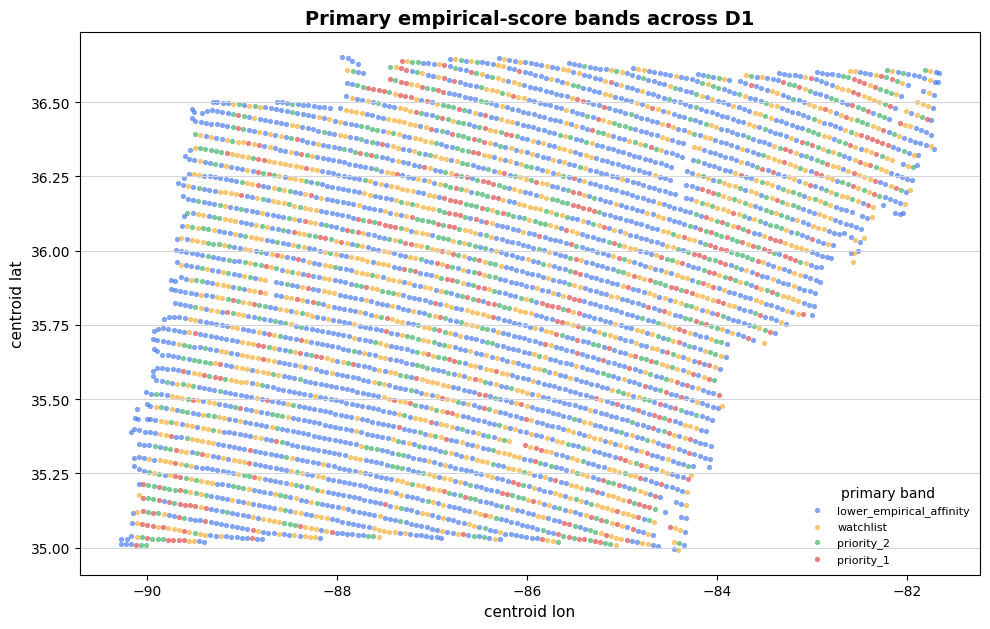

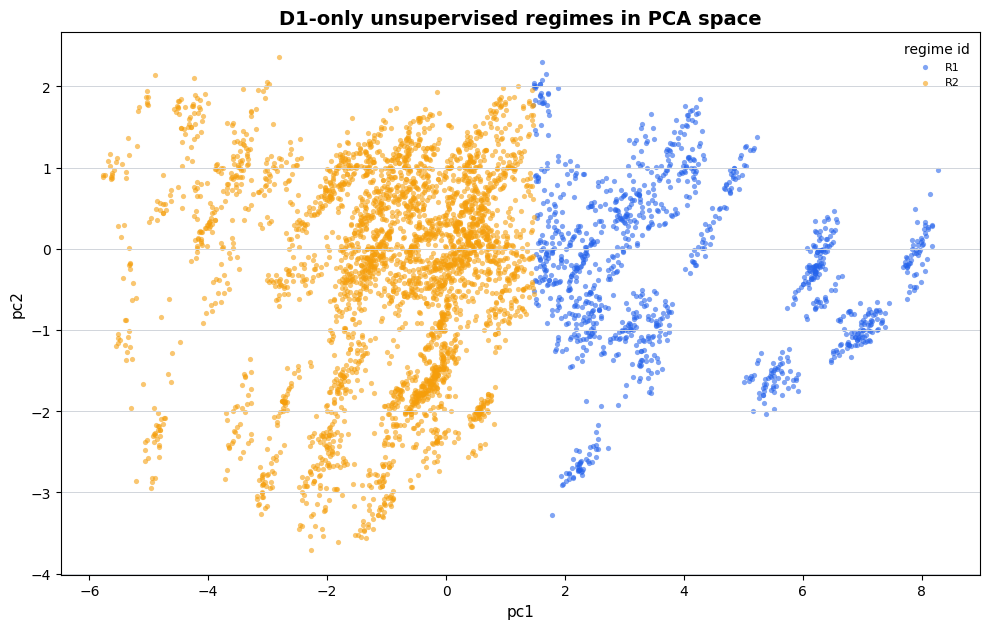

Wrote:
/Users/steve/Project/UTK/outputs/Data center/TN/model/phase 3/results/figures/phase3_unsupervised_regimes.png
/Users/steve/Project/UTK/outputs/Data center/TN/model/phase 3/results/figures/phase3_final_score_map.png
/Users/steve/Project/UTK/outputs/Data center/TN/model/phase 3/results/figures/phase3_primary_score_map.png


In [8]:
PALETTE = ['#2563eb', '#f59e0b', '#16a34a', '#dc2626', '#7c3aed', '#0891b2', '#be123c']
def scatter_figure(frame, x, y, colour, title, path):
    apply_plot_theme(); figure, axis = plt.subplots(figsize=(10, 6.4))
    for index, (group, part) in enumerate(frame.groupby(colour, dropna=False)):
        axis.scatter(part[x], part[y], s=14, alpha=.58, color=PALETTE[index % len(PALETTE)], label=str(group), linewidths=0)
    axis.set(title=title, xlabel=x.replace('_', ' '), ylabel=y.replace('_', ' ')); axis.legend(title=colour.replace('_', ' '), frameon=False, fontsize=8)
    finish_figure(figure, Path(path))

scatter_figure(comparison, 'centroid_lon', 'centroid_lat', 'primary_band', 'Primary empirical-score bands across D1', FIGURES / 'phase3_primary_score_map.png')
scatter_figure(comparison, 'pc1', 'pc2', 'regime_id', 'D1-only unsupervised regimes in PCA space', FIGURES / 'phase3_unsupervised_regimes.png')
print('Wrote:', *(str(path) for path in FIGURES.glob('phase3_*.png')), sep='\n')


In [9]:
# Retained result workbook. Existing Phase 3 outputs are not overwritten.
OUTPUT = RESULTS / 'phase3_training_comparison_visualization.xlsx'
run_manifest = pd.DataFrame([{
    'phase2_sha256': PHASE2_SHA256, 'supervised_features': ', '.join(SUPERVISED_FEATURES),
    'unsupervised_feature_count': len(UNSUPERVISED_FEATURES), 'selected_k': selected_k,
    'd1_cells': len(D1), 'primary_draws': 20, 'spatial_validation_runs': len(spatial_runs),
    'ranking_rule': 'Primary supervised empirical score only; unsupervised regimes are contextual evidence.',
}])
with pd.ExcelWriter(OUTPUT, engine='openpyxl') as writer:
    run_manifest.to_excel(writer, sheet_name='Run manifest', index=False)
    validation_summary.to_excel(writer, sheet_name='Spatial validation', index=False)
    spatial_runs.to_excel(writer, sheet_name='Spatial runs', index=False)
    pd.DataFrame(full_runs).to_excel(writer, sheet_name='Primary full fits', index=False)
    cluster_diagnostics.to_excel(writer, sheet_name='K diagnostics', index=False)
    regime_summary.to_excel(writer, sheet_name='Regime comparison', index=False)
    comparison.to_excel(writer, sheet_name='D1 score and regime', index=False)
assert OUTPUT.exists() and OUTPUT.stat().st_size > 0
print(f'Wrote retained result workbook: {OUTPUT}')

Wrote retained result workbook: /Users/steve/Project/UTK/outputs/Data center/TN/model/phase 3/results/phase3_training_comparison_visualization.xlsx


In [10]:
# Final integrity checks.
assert len(spatial_runs) == 3 * 20 * 3
assert len(comparison) == 4391 and comparison['cell_id'].is_unique
assert comparison['primary_empirical_score'].between(0, 100).all()
assert comparison['regime_id'].notna().all()
assert set(comparison['evidence_state']) <= {'corroborated', 'model_only', 'regime_only', 'novel_or_unstable', 'limited_support'}
assert (FIGURES / 'phase3_primary_score_map.png').exists()
assert (FIGURES / 'phase3_unsupervised_regimes.png').exists()
print('Phase 3 training, comparison, and visualization checks passed.')

Phase 3 training, comparison, and visualization checks passed.
